In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
from typing import cast
from sklearn.utils import Bunch
from sklearn.pipeline import Pipeline

In [3]:
data = cast(Bunch,load_iris(as_frame=True))
df = data.frame

In [4]:
X , y , features_name, labels = data.data, data.target, data.feature_names, data.target_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline = Pipeline([
    ("dtree", DecisionTreeClassifier())
])

param_grid = {
    "dtree__max_depth": [3, 5],
    "dtree__min_samples_split": [2, 5, 10],
    "dtree__min_samples_leaf": [1, 2, 4],
    "dtree__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(estimator=pipeline,
                    param_grid= param_grid,
                    cv= 5,
                    n_jobs= -1
                    )

model = grid.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [5]:
print(grid.best_params_)
print("-------------")
print(grid.best_score_)

{'dtree__criterion': 'entropy', 'dtree__max_depth': 5, 'dtree__min_samples_leaf': 4, 'dtree__min_samples_split': 2}
-------------
0.9583333333333334


In [6]:
random_search = RandomizedSearchCV(estimator=pipeline,
                                   param_distributions= param_grid,
                                   random_state= 42,
                                   n_jobs = -1,
                                    scoring="neg_mean_squared_error")

model = random_search.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(cm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


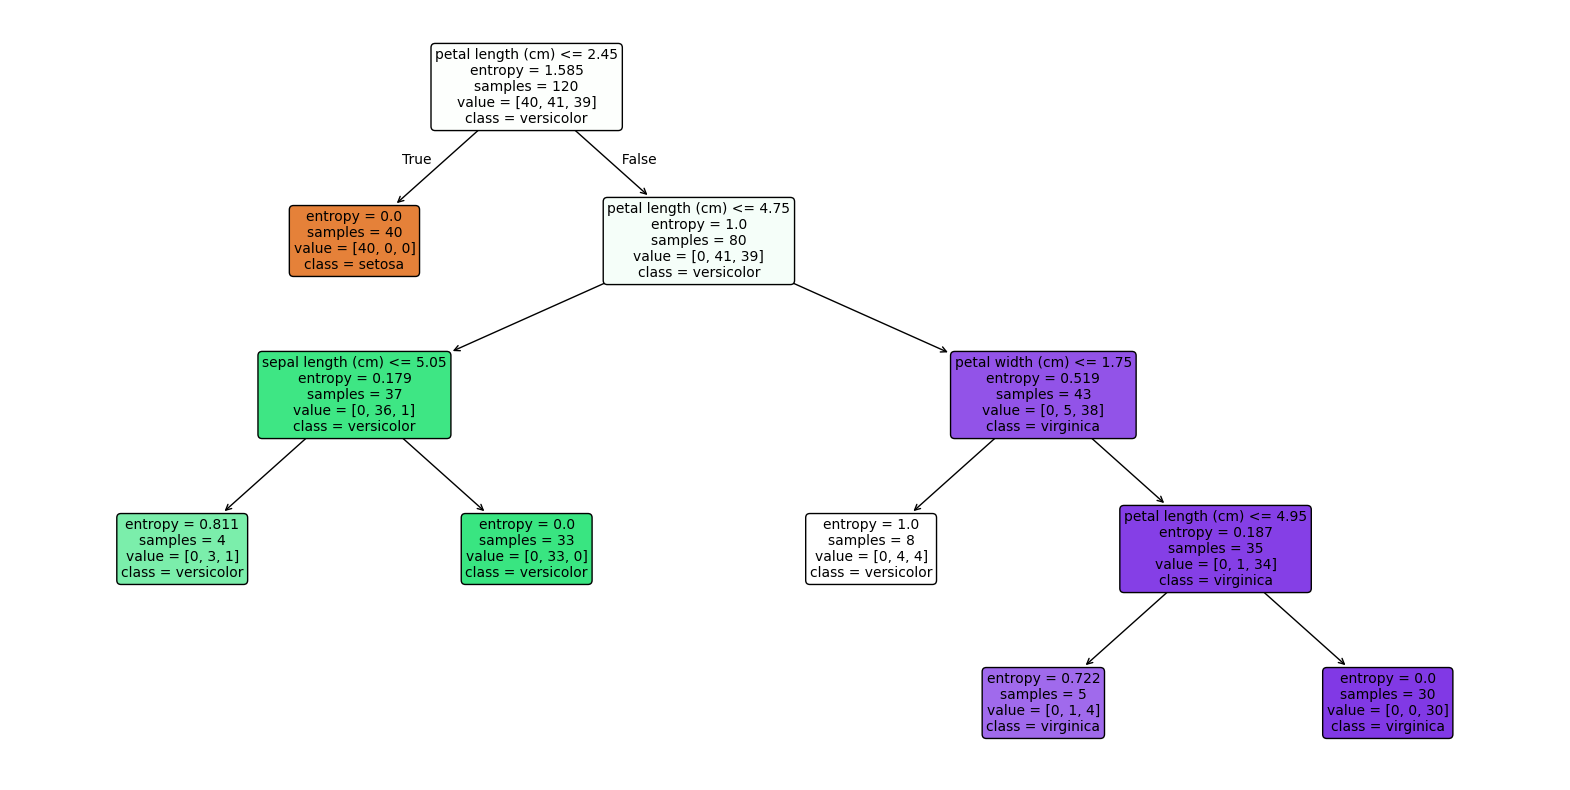

In [7]:
best_model = model.best_estimator_
plt.figure(figsize=(20,10))

plot_tree(
    best_model.named_steps["dtree"],
    feature_names= features_name,
    class_names= labels,
    filled=True,
    rounded=True, 
    fontsize=10
)
plt.show()